## Load the Iris dataset

# Iris Flower Classification

## Project Overview

This project uses machine learning to classify iris flowers into three species: Setosa, Versicolor, and Virginica based on their physical measurements.

The Iris dataset contains four features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The project includes exploratory data analysis, data visualization, feature selection, model training, and evaluation of multiple classification algorithms.

## 1. Import Required Libraries

In this project, we use Pandas for data manipulation, NumPy for numerical operations, Matplotlib and Seaborn for visualization, and Scikit-learn for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Iris Dataset

The Iris dataset is a built-in dataset provided by Scikit-learn. It contains 150 observations belonging to three different iris species, with four numerical measurements for each flower.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

## 3. Create the DataFrame

The Iris dataset is provided by Scikit-learn as a dataset object. We convert the feature data into a Pandas DataFrame so that we can easily inspect, clean, analyze, and visualize the data.

In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4. Convert Target Values to Species Names

The target variable is initially represented by numeric labels: 0, 1, and 2. These values correspond to Setosa, Versicolor, and Virginica respectively. Converting them to meaningful names makes the data easier to understand and interpret.

In [4]:
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is the process of examining the dataset to understand its structure, data types, missing values, distributions, and important patterns before building a machine learning model.

### 5.1 Dataset Shape

The shape of the dataset tells us the number of rows and columns present in the dataset.

In [5]:
df.shape

(150, 5)

### 5.2 Data Types

Checking the data types helps us understand how each column is stored and whether any columns need to be converted before analysis or model training.

In [6]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

### 5.3 Missing Value Check

Missing values can affect data analysis and machine learning models. We check each column to determine whether any values are missing in the dataset.

In [7]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### 5.4 Descriptive Statistics

Descriptive statistics provide a summary of the numerical features in the dataset, including the count, mean, standard deviation, minimum, maximum, and quartile values.

In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 6. Exploratory Data Visualization

Visualizations help us understand relationships between features and identify patterns that may help distinguish the three iris species.

### 6.1 Pairplot

A pairplot shows the relationship between every pair of numerical features and uses different colors for each iris species. This helps us visually identify which features are most useful for separating the classes.

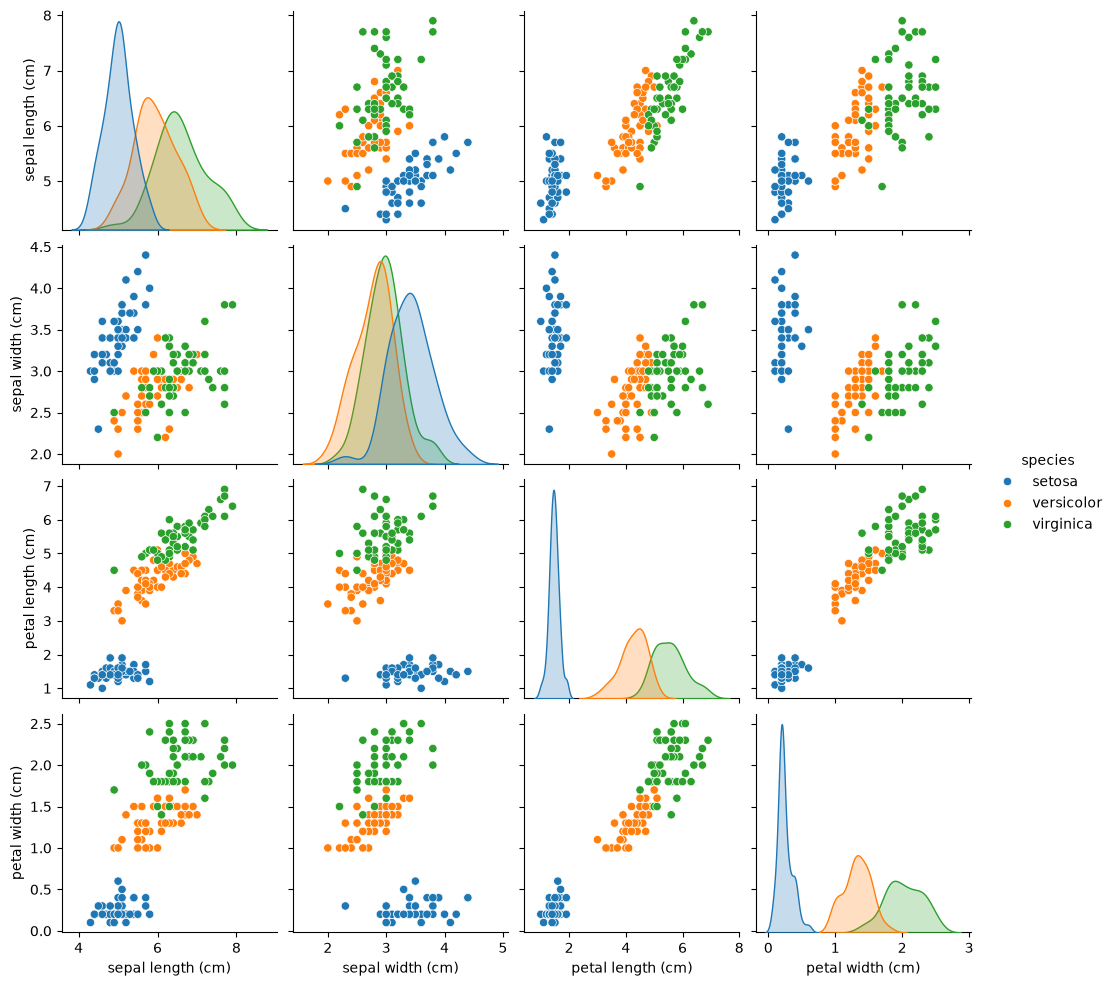

In [9]:
sns.pairplot(df, hue="species")
plt.show()

### Pairplot Observations

The pairplot shows the relationships between the four numerical features for the three iris species. Setosa is clearly separated from the other two species across several feature combinations. Petal length and petal width show the clearest separation between the species, while the sepal features have more overlap. Therefore, petal length and petal width appear to be the most discriminative features for classifying the iris species.

### 6.2 Box Plots

Box plots are used to compare the distribution of each numerical feature across the three iris species. They show the median, quartiles, spread, and potential outliers.

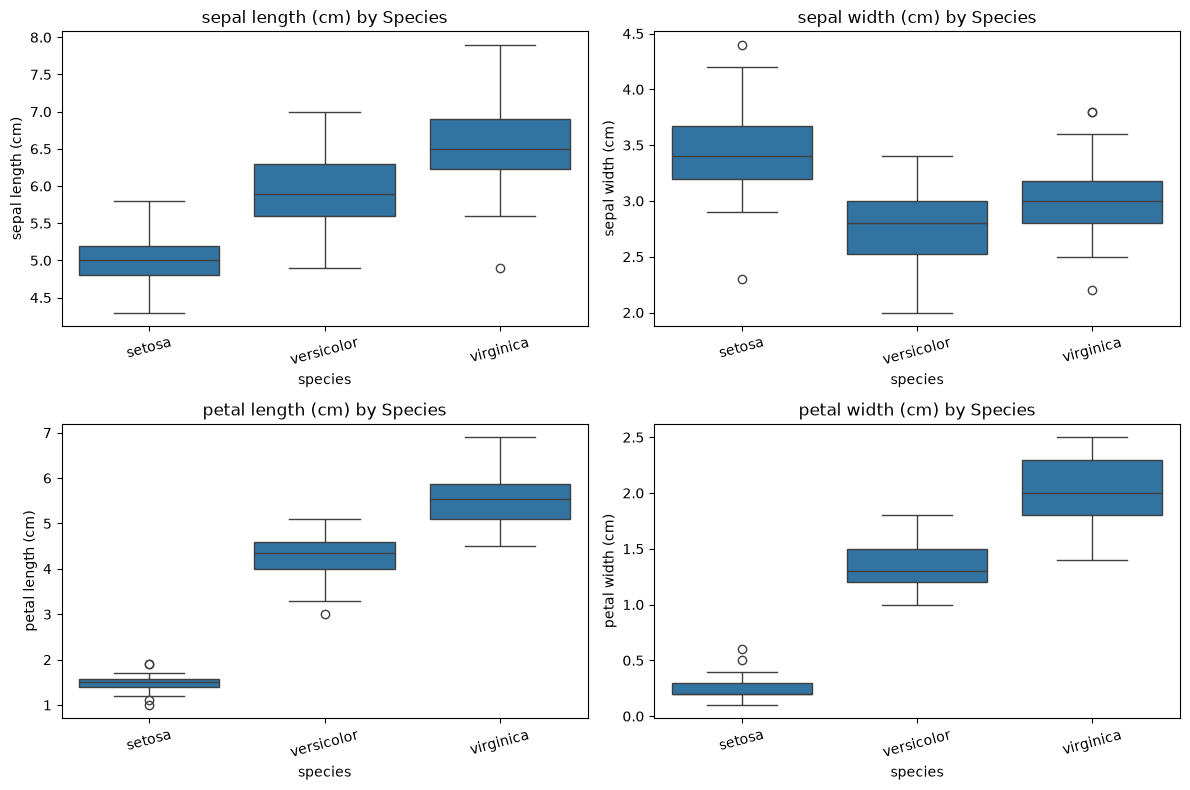

In [10]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 7. Prepare Data for Machine Learning

The dataset is divided into features and a target variable. The four flower measurements are used as input features, while the iris species is the target that the machine learning models will predict.

In [11]:
X = df[iris.feature_names]
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## 8. Train-Test Split

The dataset is divided into training and testing sets. We use 80% of the data for training the machine learning models and 20% for evaluating their performance on unseen data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


## 9. Model Training

We will train multiple classification algorithms and compare their performance. Logistic Regression will be used as the first classification model.

### 9.1 Logistic Regression

Logistic Regression is a commonly used classification algorithm that estimates the probability of an observation belonging to a particular class. It is suitable for multi-class classification problems such as the Iris dataset.

In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


### 9.2 Logistic Regression Evaluation

The Logistic Regression model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score. These metrics help us understand how well the model correctly classifies the three iris species.

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Logistic Regression Results

The Logistic Regression model achieved an accuracy of 96.67% on the test dataset. The model classified all Setosa samples correctly. For Versicolor, the recall was 90%, while Virginica achieved a recall of 100%. The results indicate that Logistic Regression performs very well on the Iris dataset, with the small amount of misclassification occurring between the more similar Versicolor and Virginica classes.

### 9.3 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each iris species. Correct predictions appear along the diagonal, while incorrect predictions appear outside the diagonal.

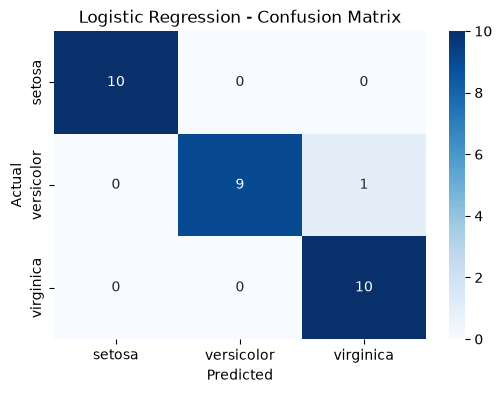

In [15]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Confusion Matrix Observations

The confusion matrix shows that Logistic Regression correctly classified all 10 Setosa and all 10 Virginica samples. Out of 10 Versicolor samples, 9 were correctly classified and 1 was incorrectly classified as Virginica. Overall, 29 out of 30 test samples were correctly classified, resulting in an accuracy of 96.67%.

## 10. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions. Each tree makes a prediction, and the final class is determined based on the combined predictions of the trees.

In [16]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf)

Random Forest predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


### 10.1 Random Forest Evaluation

The Random Forest model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. These results will later be compared with the Logistic Regression model to identify the best-performing classifier.

In [17]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Random Forest Results

The Random Forest classifier achieved an accuracy of 90% on the test dataset. It correctly classified all Setosa samples, but some Versicolor and Virginica samples were misclassified. Virginica had a recall of 80%, indicating that 20% of the actual Virginica samples were incorrectly classified. Compared with Logistic Regression, Random Forest achieved lower accuracy on this test set.

### 10.2 Random Forest Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Random Forest classifier for each iris species.

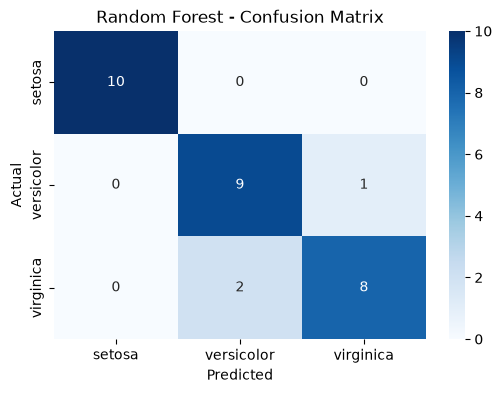

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=random_forest_model.classes_,
    yticklabels=random_forest_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

### Random Forest Confusion Matrix Observations

The confusion matrix shows that Random Forest correctly classified all 10 Setosa samples. It correctly classified 9 out of 10 Versicolor samples, while 1 was classified as Virginica. For Virginica, 8 out of 10 samples were correctly classified and 2 were classified as Versicolor. The model therefore correctly classified 27 out of 30 test samples, resulting in an accuracy of 90%.

## 11. Model Comparison

The performance of Logistic Regression and Random Forest is compared using their accuracy scores. The model with the higher test accuracy will be selected as the best-performing model for this dataset.

In [19]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_logistic, accuracy_rf]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.966667
1,Random Forest,0.900000


### Best-Performing Model

Based on the test results, Logistic Regression is the best-performing model for this Iris classification task. It achieved an accuracy of 96.67%, compared with 90% for Random Forest. Therefore, Logistic Regression is selected as the best model because it produced higher classification accuracy on the test dataset.

## 12. Feature Selection Analysis

The visual analysis suggested that petal length and petal width are the most discriminative features. We will examine the Logistic Regression coefficients to further understand the contribution of each feature to the classification model.

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient Magnitude": np.mean(
        np.abs(logistic_model.coef_),
        axis=0
    )
})

feature_importance = feature_importance.sort_values(
    by="Coefficient Magnitude",
    ascending=False
)

feature_importance

,Feature,Coefficient Magnitude
2,petal length (cm),1.678885
3,petal width (cm),1.232974
1,sepal width (cm),0.551510
0,sepal length (cm),0.353140


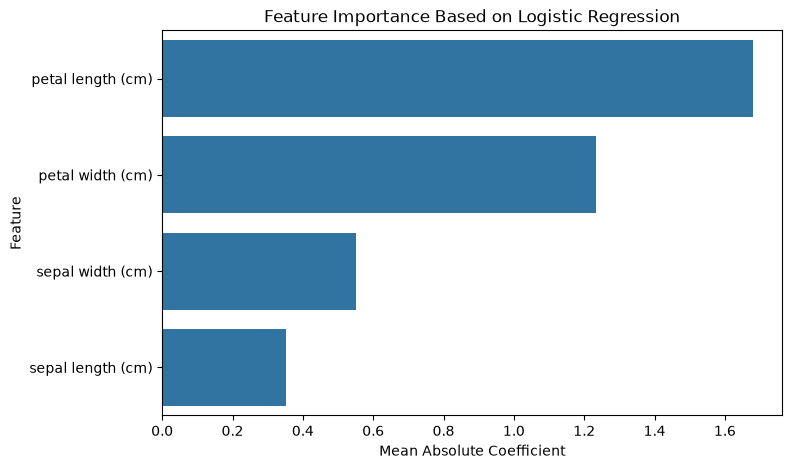

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Coefficient Magnitude",
    y="Feature"
)

plt.title("Feature Importance Based on Logistic Regression")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

### Feature Selection Conclusion

The feature importance analysis shows that petal length and petal width have the highest coefficient magnitudes in the Logistic Regression model. This agrees with the patterns observed in the pairplot and box plots. Therefore, petal length and petal width are the most discriminative features for identifying the iris species, while sepal length has the lowest coefficient magnitude among the four features.

## 13. Final Conclusion

In this project, we performed exploratory data analysis and built machine learning classification models to identify iris flower species.

The dataset contained 150 samples and four numerical features: sepal length, sepal width, petal length, and petal width. Exploratory analysis showed that petal length and petal width provide the clearest separation between the three species.

Two classification models were trained and evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved an accuracy of 96.67%, while Random Forest achieved 90% accuracy. Therefore, Logistic Regression was selected as the best-performing model for this dataset.

Feature analysis also showed that petal length and petal width were the most influential features for classification.

This project provided practical experience in data preprocessing, exploratory data analysis, visualization, machine learning model training, and model evaluation.